In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(42)

In [60]:
# ── Distribution parameters ──────────────────────────────────────────────────
N_DENSE   = 10
N_EACH    = 1_000_000
N_SPARSE  = 10
N_OUTLIER = 1_000_000
N_OUTLIER_PTS = 10
OUTLIER_POINT_SIZE = 4

# Coordinate space: roughly [-10, 10] x [-10, 10]
SPACE = 10.0

# Random means for the 10 dense classes
dense_means = rng.uniform(-SPACE * 0.8, SPACE * 0.8, size=(N_DENSE, 2))
dense_stds  = rng.uniform(0.3, 1.2, size=N_DENSE)

# Colors: 10 dense classes get a tab10 palette,
# sparse class = bright yellow, outlier class = bright magenta
tab10 = plt.get_cmap("tab10")
dense_colors   = [np.array(tab10(i)[:3]) for i in range(N_DENSE)]
sparse_color   = np.array([1.0, 0.9, 0.0])   # yellow
outlier_color  = np.array([1.0, 0.0, 1.0])   # magenta

# ── Generate point clouds ────────────────────────────────────────────────────
dense_points = []
for i in range(N_DENSE):
    pts = rng.normal(loc=dense_means[i], scale=dense_stds[i], size=(N_EACH, 2))
    dense_points.append(pts)

sparse_points = rng.uniform(-SPACE, SPACE, size=(N_SPARSE, 2))

outlier_main = rng.normal(loc=[2.0, -3.0], scale=1.0, size=(N_OUTLIER, 2))
outlier_pts  = rng.uniform(-SPACE * 0.9, SPACE * 0.9, size=(N_OUTLIER_PTS, 2))
outlier_points = np.vstack([outlier_main, outlier_pts])

# Collect all classes as (points, color, label)
all_classes = (
    [(dense_points[i], dense_colors[i], f"Dense {i}") for i in range(N_DENSE)]
    + [(sparse_points,  sparse_color,  "Sparse")]
    + [(outlier_points, outlier_color, "Outlier")]
)

print(f"Total classes: {len(all_classes)}")
print(f"Dense class sizes: {[len(p) for p,_,_ in all_classes[:10]]}")
print(f"Sparse size: {len(sparse_points)}, Outlier size: {len(outlier_points)}")

Total classes: 12
Dense class sizes: [1000000, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000]
Sparse size: 10, Outlier size: 1000010


In [61]:
# ── Compute 2-D histograms ────────────────────────────────────────────────────
BINS = 200
BIN_RANGE = [[-SPACE, SPACE], [-SPACE, SPACE]]

hists   = []   # raw counts  (BINS x BINS)
colors  = []   # RGB arrays
labels  = []

for pts, col, lbl in all_classes:
    h, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=BINS, range=BIN_RANGE)
    hists.append(h)
    colors.append(col)
    labels.append(lbl)

hists  = np.array(hists)   # (n_classes, 200, 200)
colors = np.array(colors)  # (n_classes, 3)

# Log-normalised density per class (used by most visualisations)
def log_norm(h):
    """Map counts -> [0,1] via log1p, then normalise to max."""
    l = np.log1p(h)
    m = l.max()
    return l / m if m > 0 else l

log_hists = np.stack([log_norm(h) for h in hists])  # (n_classes, 200, 200)

print("Histogram stack shape:", hists.shape)
print("Max counts per class:", hists.max(axis=(1,2)))
OUTLIER_PERCENTILE = 10  # bottom X% of non-zero bins per class are flagged as outlier cells

Histogram stack shape: (12, 200, 200)
Max counts per class: [1.7280e+03 4.1840e+03 1.1970e+03 1.3570e+03 1.6500e+03 7.2680e+03
 3.1050e+03 1.3552e+04 8.3480e+03 1.9210e+03 1.0000e+00 1.6210e+03]


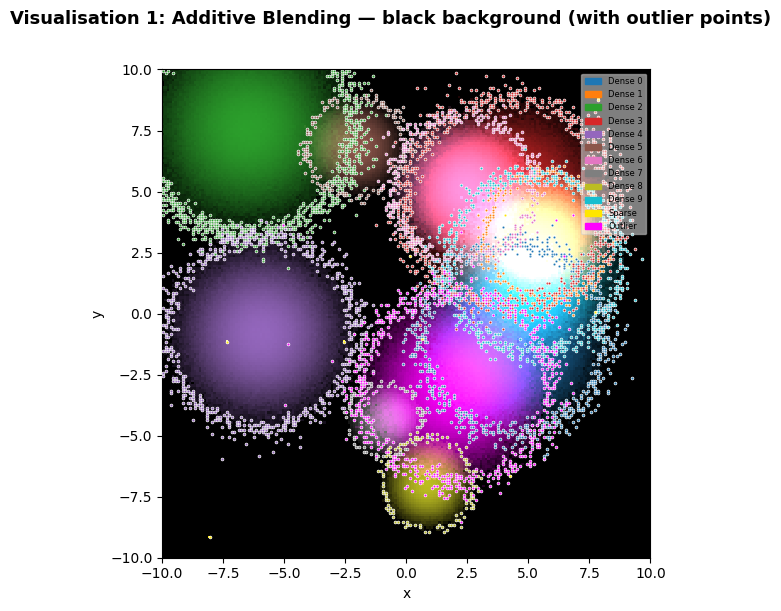

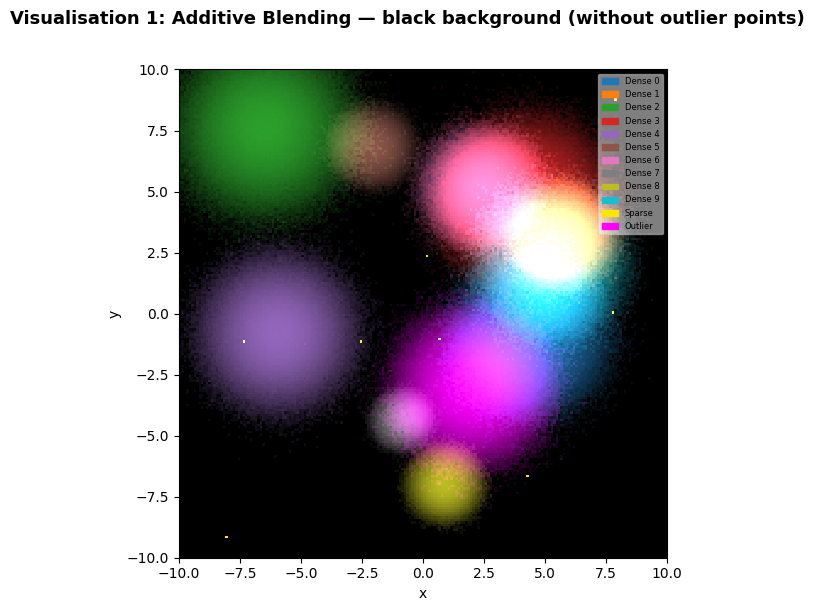

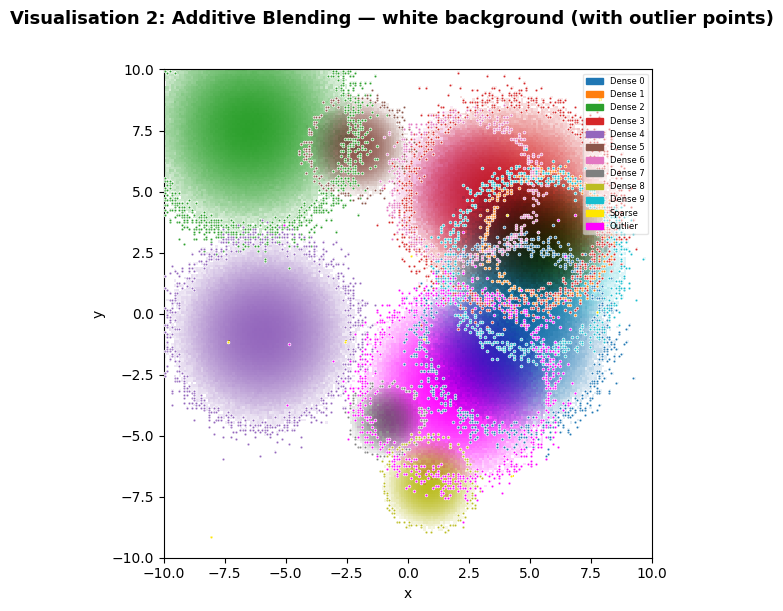

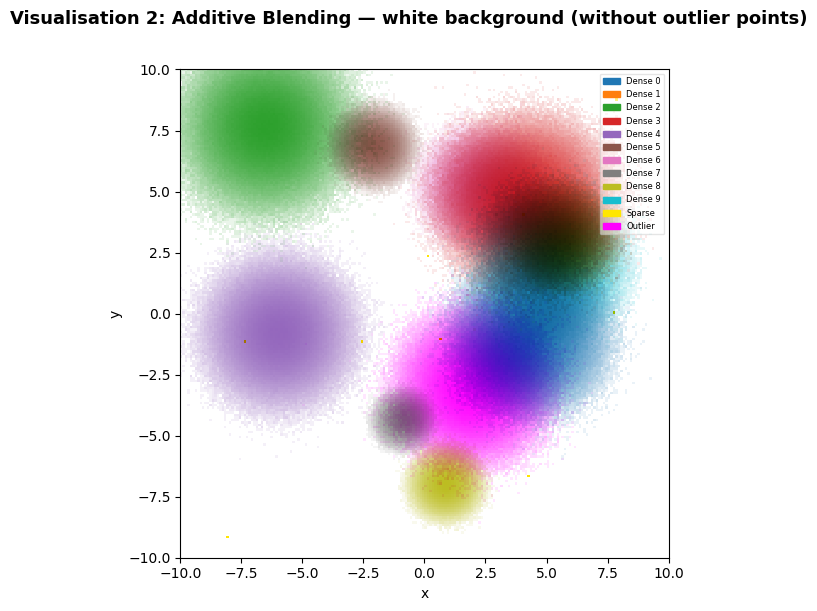

In [62]:
# ── Helper: save / show figure ────────────────────────────────────────────────
def show(fig, title):
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

def legend_patches(colors, labels):
    return [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]

# ── Helper: overlay outlier-cell scatter points ───────────────────────────────
def draw_outlier_points(ax, hists, cols, labels, bins=BINS, space=SPACE, percentile=OUTLIER_PERCENTILE):
    """
    For each class, find bins whose log-normalised count falls in the bottom
    `percentile`% of that class's non-zero bins.  Draw those bin centres as
    scatter points with class-colour fill and a white border.
    """
    bin_width = (2 * space) / bins
    # bin-centre coordinates
    centres = np.linspace(-space + bin_width / 2, space - bin_width / 2, bins)

    for i, (col, lbl) in enumerate(zip(cols, labels)):
        h = hists[i]                          # (bins_x, bins_y)  — histogram2d axes
        log_h = np.log1p(h)
        nonzero = log_h[log_h > 0]
        if nonzero.size == 0:
            continue
        threshold = np.percentile(nonzero, percentile)
        # mask: non-zero AND below threshold
        mask = (log_h > 0) & (log_h <= threshold)   # (bins_x, bins_y)
        xi, yi = np.where(mask)                      # indices in (x-bin, y-bin) space
        if xi.size == 0:
            continue
        xs = centres[xi]
        ys = centres[yi]
        ax.scatter(xs, ys, s=OUTLIER_POINT_SIZE, color=col, edgecolors="white",
                   linewidths=0.5, zorder=5, label=f"{lbl} outlier cells")

# ── Viz 1 & 2 : Additive colour blending ─────────────────────────────────────
def additive_blend(log_h, cols, background="black"):
    if background == "black":
        # Additive: sum density_i * color_i onto black canvas
        canvas = np.zeros((*log_h.shape[1:], 3), dtype=np.float64)
        for i in range(len(cols)):
            canvas += log_h[i, :, :, None] * cols[i]
        canvas = np.clip(canvas, 0, 1)
    else:
        # Subtractive on white: start at 1 and multiply down toward class color
        # Each class pulls the canvas toward its hue proportional to density
        canvas = np.ones((*log_h.shape[1:], 3), dtype=np.float64)
        for i in range(len(cols)):
            # density=0 → no change; density=1 → full class color
            canvas *= 1.0 - log_h[i, :, :, None] * (1.0 - cols[i])
        canvas = np.clip(canvas, 0, 1)

    return np.transpose(canvas, (1, 0, 2))

for bg in ["black", "white"]:
    for show_outliers in [True, False]:
        fig, ax = plt.subplots(figsize=(7, 6))
        img = additive_blend(log_hists, colors, background=bg)
        ax.imshow(img, origin="lower", extent=[-SPACE, SPACE, -SPACE, SPACE],
                  interpolation="nearest")
        ax.set_facecolor(bg)
        if show_outliers:
            draw_outlier_points(ax, hists, colors, labels)
        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.legend(handles=legend_patches(colors, labels),
                  loc="upper right", fontsize=6, framealpha=0.5)
        suffix = "with outlier points" if show_outliers else "without outlier points"
        viz_num = '1' if bg == 'black' else '2'
        show(fig, f"Visualisation {viz_num}: Additive Blending — {bg} background ({suffix})")

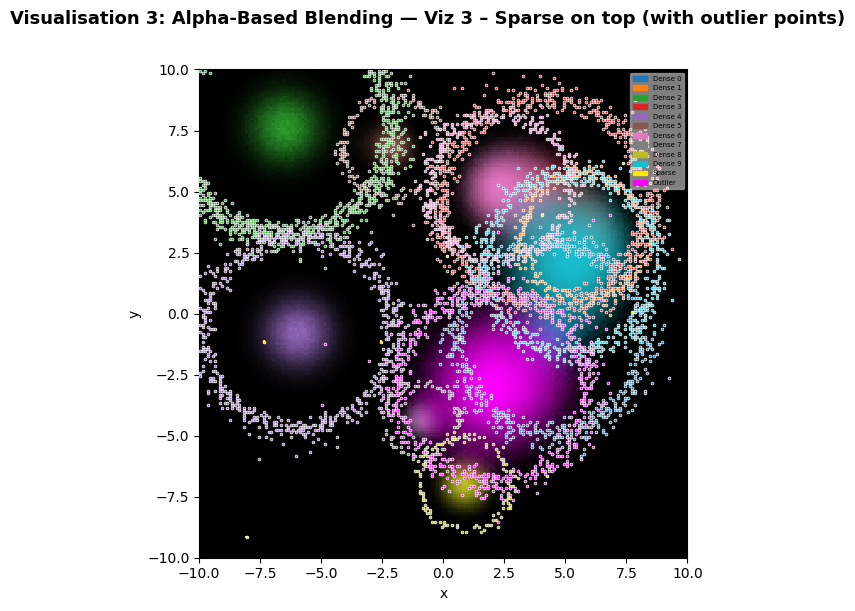

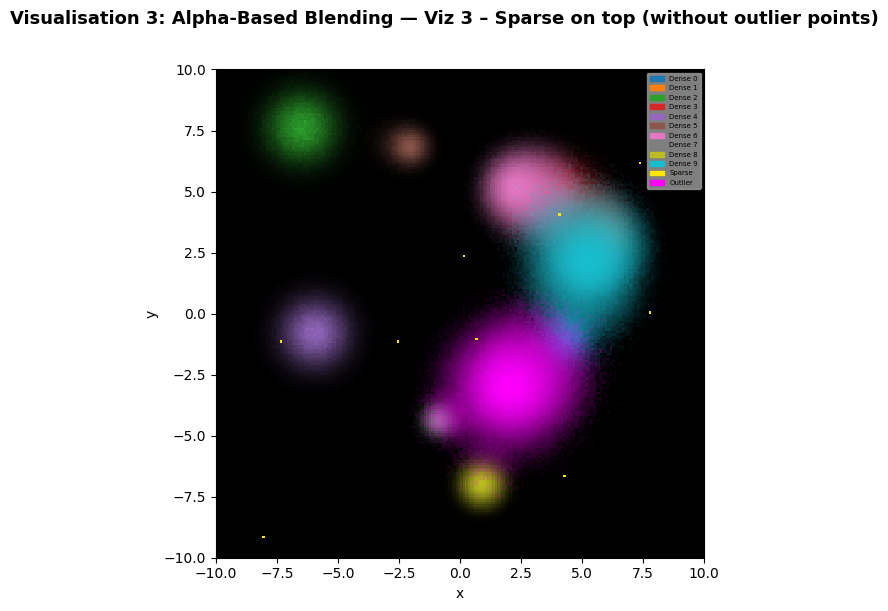

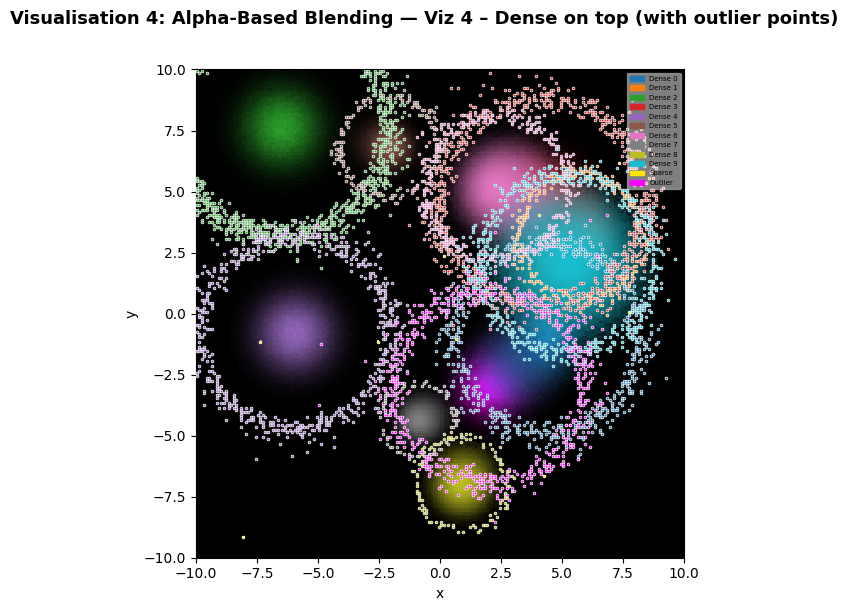

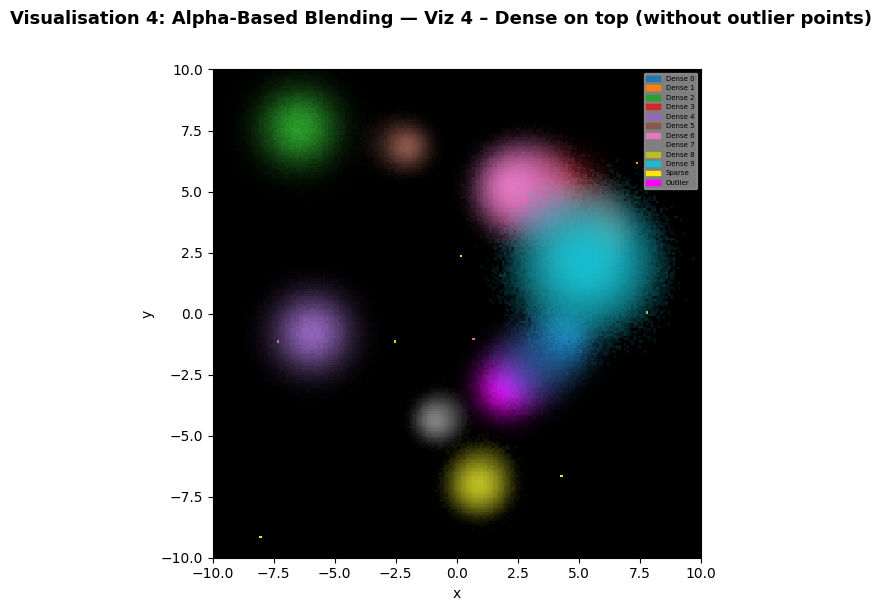

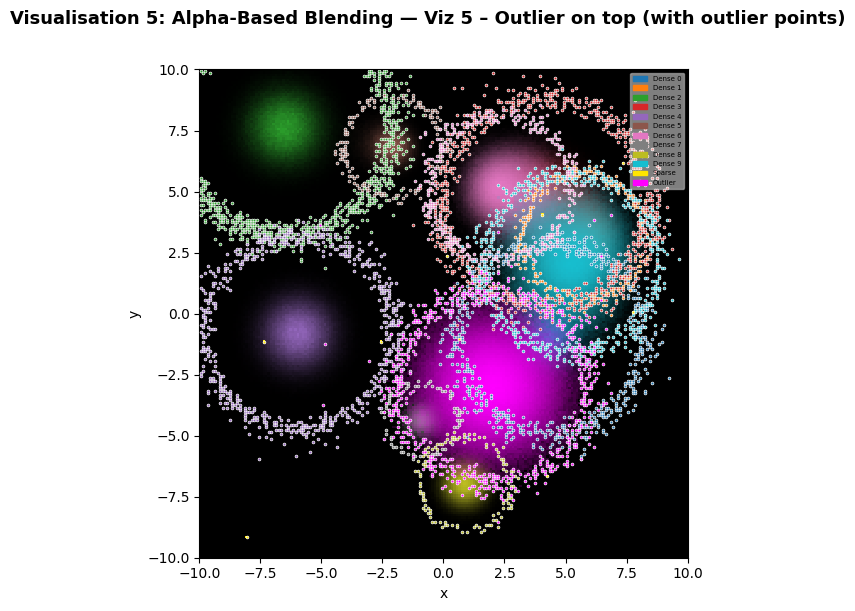

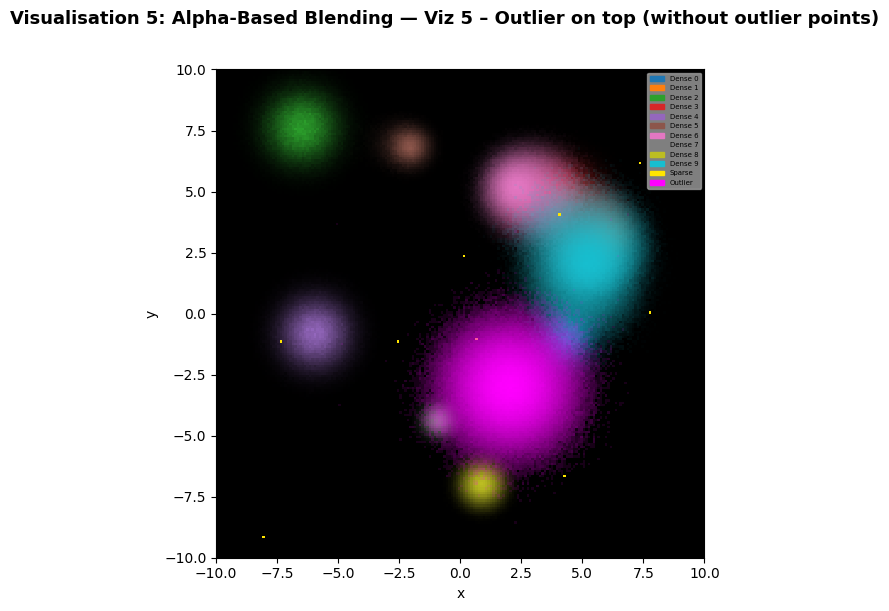

In [63]:
# ── Viz 3–5 : Alpha-based blending (painter's algorithm) ─────────────────────
def alpha_blend_ordered(log_h, cols, order):
    """
    Render classes in `order` (back to front).
    Each class contributes RGBA where A = density value.
    """
    H, W = log_h.shape[1], log_h.shape[2]
    canvas = np.zeros((H, W, 4), dtype=np.float64)   # RGBA, starts transparent

    for idx in order:
        alpha = log_h[idx]                            # (H, W)
        src   = np.concatenate([cols[idx], [1.0]])    # RGBA source colour, opaque
        # Standard alpha compositing: dst = src*alpha + dst*(1-alpha)
        canvas[..., :3] = (
            src[:3] * alpha[:, :, None] * src[3]
            + canvas[..., :3] * canvas[..., 3:4] * (1 - alpha[:, :, None] * src[3])
        )
        canvas[..., 3] = (
            src[3] * alpha
            + canvas[..., 3] * (1 - src[3] * alpha)
        )

    rgb = np.clip(canvas[..., :3], 0, 1)
    return np.transpose(rgb, (1, 0, 2))

# Class index legend:
# 0-9  → dense classes
# 10   → sparse
# 11   → outlier

dense_idx   = list(range(10))
sparse_idx  = 10
outlier_idx = 11

orders = {
    "Viz 3 – Sparse on top":  dense_idx + [outlier_idx, sparse_idx],
    "Viz 4 – Dense on top":   [sparse_idx, outlier_idx] + dense_idx,
    "Viz 5 – Outlier on top": dense_idx + [sparse_idx, outlier_idx],
}

for i, (title, order) in enumerate(orders.items(), start=3):
    for show_outliers in [True, False]:
        fig, ax = plt.subplots(figsize=(7, 6))
        img = alpha_blend_ordered(log_hists, colors, order)
        ax.imshow(img, origin="lower", extent=[-SPACE, SPACE, -SPACE, SPACE],
                  interpolation="nearest")
        if show_outliers:
            draw_outlier_points(ax, hists, colors, labels)
        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.legend(handles=legend_patches(colors, labels),
                  loc="upper right", fontsize=5, framealpha=0.5)
        suffix = "with outlier points" if show_outliers else "without outlier points"
        show(fig, f"Visualisation {i}: Alpha-Based Blending — {title} ({suffix})")

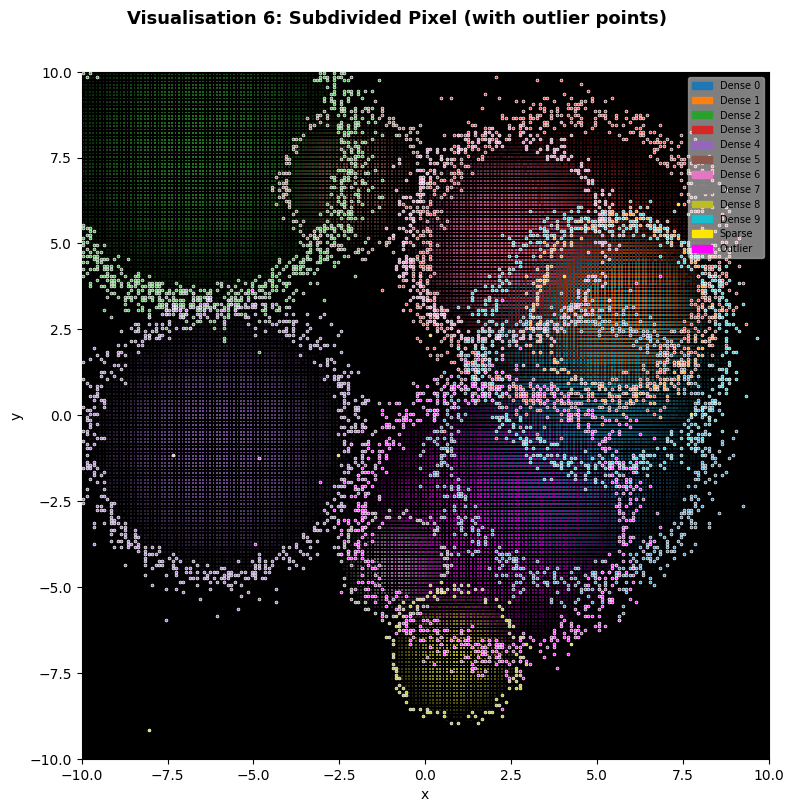

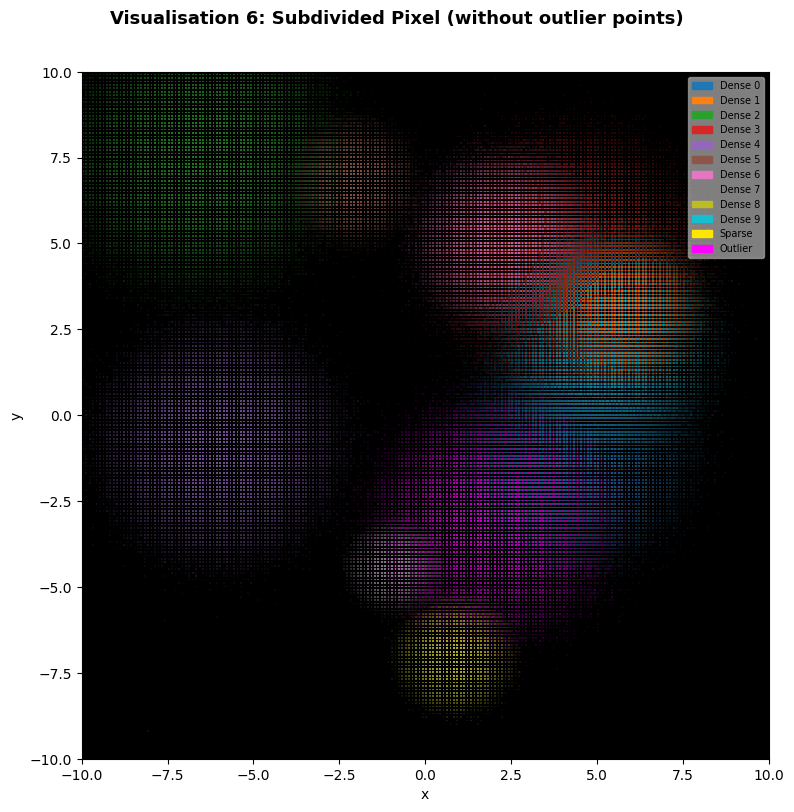

In [64]:
# ── Viz 6 : Subdivided pixel (2×2 sub-pixels, top-4 classes per bin) ─────────
def subdivided_pixel(hists, cols, bins=BINS):
    """
    Each bin is rendered as a 2×2 block of sub-pixels.
    The 4 sub-pixels show the colours of the top-4 classes by raw count.
    Brightness of each sub-pixel is scaled by the log-normalised density
    of that ranked class (relative to the global max), so denser bins
    appear brighter.
    """
    sub = 2
    out = np.zeros((bins * sub, bins * sub, 3), dtype=np.float64)

    h_yx = np.transpose(hists, (0, 2, 1))        # (n_classes, bins_y, bins_x)
    ranked = np.argsort(-h_yx, axis=0)            # (n_classes, bins_y, bins_x)

    # Log-normalise counts globally so brightness is comparable across ranks
    log_h = np.log1p(h_yx)
    global_max = log_h.max() + 1e-12
    log_h_norm = log_h / global_max              # (n_classes, bins_y, bins_x)

    sub_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    for rank, (dr, dc) in enumerate(sub_positions):
        class_idx = ranked[rank]                  # (bins_y, bins_x)
        # brightness = log-normalised density of this rank's class
        brightness = np.take_along_axis(
            log_h_norm, ranked[rank:rank+1], axis=0
        )[0]                                      # (bins_y, bins_x)
        pixel_colors = cols[class_idx] * brightness[:, :, None]
        out[dr::sub, dc::sub] = pixel_colors

    return out

img6 = subdivided_pixel(hists, colors)

for show_outliers in [True, False]:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img6, origin="lower", interpolation="nearest",
              extent=[-SPACE, SPACE, -SPACE, SPACE])
    ax.set_facecolor("black")
    if show_outliers:
        draw_outlier_points(ax, hists, colors, labels)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(handles=legend_patches(colors, labels),
              loc="upper right", fontsize=7, framealpha=0.5)
    suffix = "with outlier points" if show_outliers else "without outlier points"
    show(fig, f"Visualisation 6: Subdivided Pixel ({suffix})")

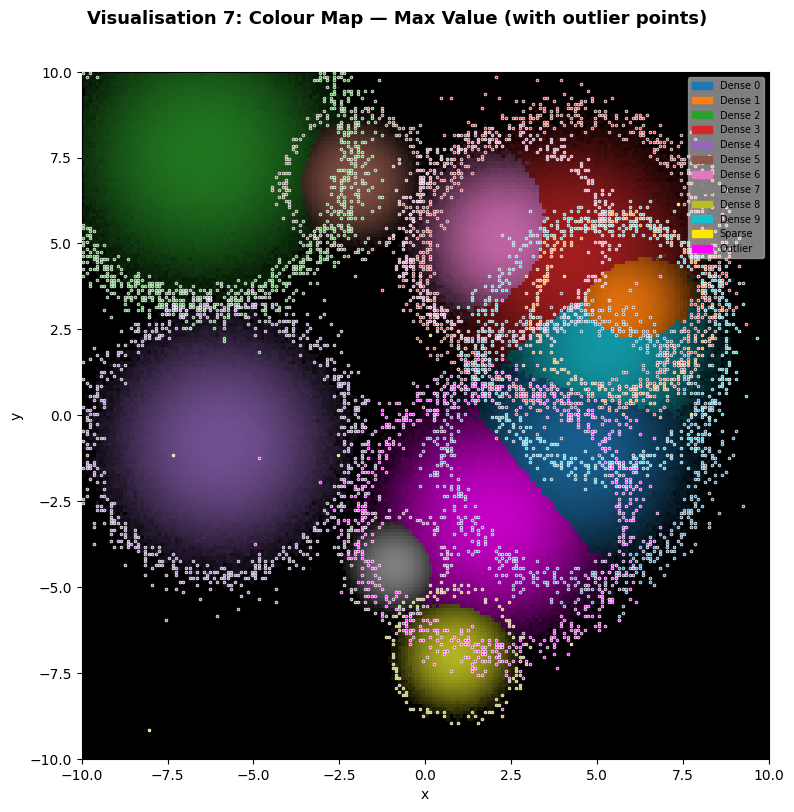

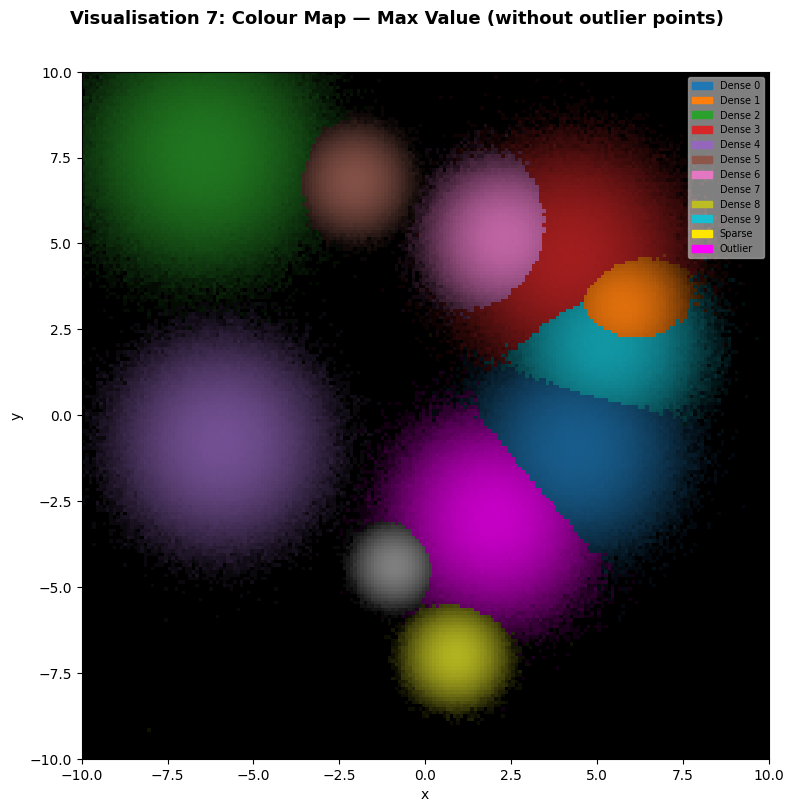

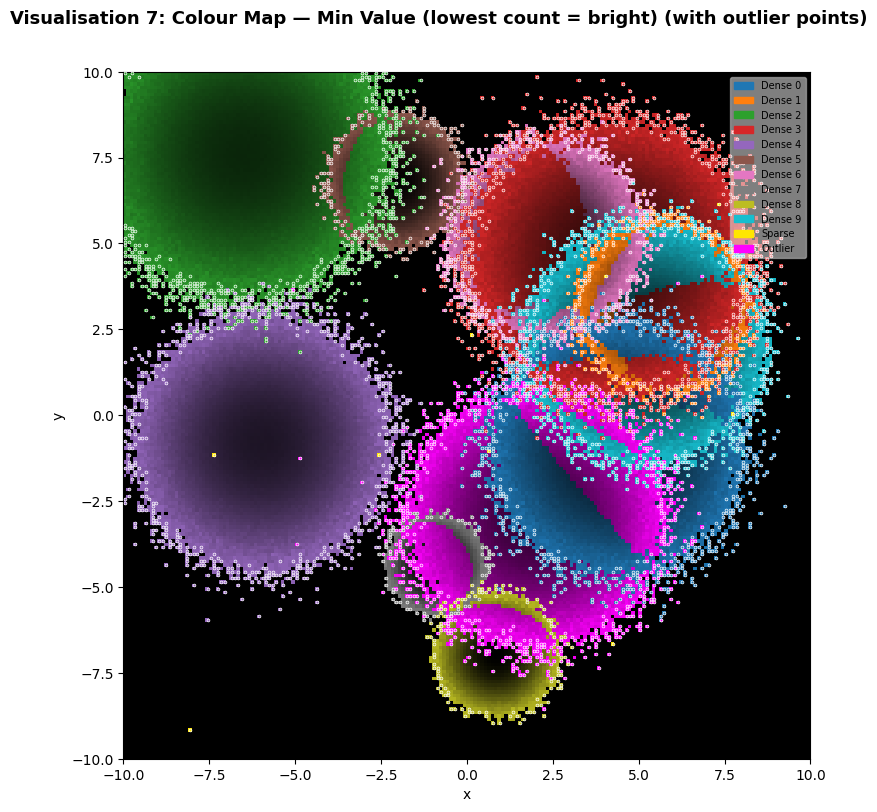

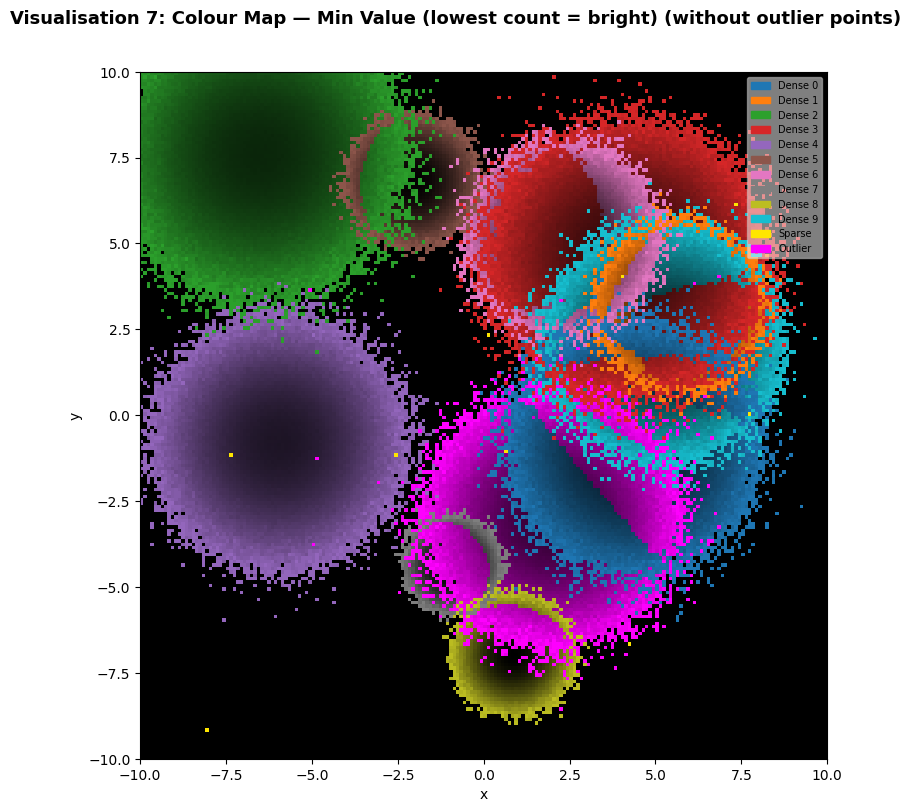

In [65]:
# ── Viz 7 : Max-value / Min-value colouring ───────────────────────────────────
def max_value_map(hists, cols):
    """Each bin coloured by the class with the highest raw count."""
    winner = np.argmax(hists, axis=0)
    winner_h = hists[winner, np.arange(BINS)[:, None], np.arange(BINS)[None, :]]
    bright = np.log1p(winner_h)
    bright = bright / (bright.max() + 1e-12)
    img = cols[winner] * bright[:, :, None]
    return np.transpose(img, (1, 0, 2))

def min_value_map(hists, cols):
    """Each bin coloured by the class with the lowest non-zero raw count,
    with brightness inversely proportional to that count (lowest = brightest)."""
    hists_nonzero = np.where(hists > 0, hists, np.inf)
    winner = np.argmin(hists_nonzero, axis=0)
    winner_h = hists[winner, np.arange(BINS)[:, None], np.arange(BINS)[None, :]]
    any_nonzero = hists.max(axis=0) > 0

    # Invert: high log-count → low brightness, low log-count → high brightness
    log_w = np.log1p(winner_h)
    log_max = log_w[any_nonzero].max() if any_nonzero.any() else 1.0
    bright = np.where(any_nonzero, 1.0 - log_w / (log_max + 1e-12), 0.0)
    # Rescale so the brightest occupied bin = 1
    bmax = bright.max()
    bright = bright / (bmax + 1e-12)

    img = cols[winner] * bright[:, :, None]
    return np.transpose(img, (1, 0, 2))

img7     = max_value_map(hists, colors)
img7_inv = min_value_map(hists, colors)

for img, label in [(img7, "Max Value"), (img7_inv, "Min Value (lowest count = bright)")]:
    for show_outliers in [True, False]:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img, origin="lower", interpolation="nearest",
                  extent=[-SPACE, SPACE, -SPACE, SPACE])
        ax.set_facecolor("black")
        if show_outliers:
            draw_outlier_points(ax, hists, colors, labels)
        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.legend(handles=legend_patches(colors, labels),
                  loc="upper right", fontsize=7, framealpha=0.5)
        suffix = "with outlier points" if show_outliers else "without outlier points"
        show(fig, f"Visualisation 7: Colour Map — {label} ({suffix})")